In [279]:
# using rapids
# export as adata_myofiber.h5ad

In [280]:
# must be on gpu
# see https://github.com/CooperStansbury/hematokytos/blob/main/notebooks/reference_analysis/make_embedding.ipynb for examples
# rsc.get.anndata_to_GPU(adata)
# rsc.get.anndata_to_CPU(adata)

# https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.embedding_density.html
# consider paga
# ?silhouette_score
    # - pca
    # labels are adata.obs

In [1]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
import scipy
from scipy.stats import zscore
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
import pyranges as pr
import anndata as an
import scanpy as sc
import scanpy.external as sce
import rapids_singlecell as rsc
import cudf
import cugraph
import rmm
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator
from simple_colors import *
import palettable
rsc.__version__

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

/home/lindmuir/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# config

In [2]:
from simple_colors import *
from palettable.scientific.sequential import Batlow_9
from palettable.scientific.diverging import Berlin_9
from palettable.scientific.sequential import Oleron_9

plt.rc('figure',figsize=(5,4),fc='beige')
plt.rc('axes',grid=False,fc='beige')

sns.set_context(context='talk') # seaborn plot settings

sc.settings.set_figure_params(frameon=False,dpi=100,dpi_save=300)
sc.settings.verbosity = 3

custom_cycle = palettable.scientific.diverging.Berlin_9.mpl_colors #
# custom_cycle = palettable.scientific.sequential.Oleron_9.mpl_colors #
# custom_cycle = palettable.scientific.diverging.Batlow_9.mpl_colors #


sc.settings.set_figure_params(frameon=False,dpi=100,dpi_save=300,color_map='Spectral_r') # scanpy plot settings


In [2]:
sc.logging.print_memory_usage()

Memory usage: current 1.07 GB, difference +1.07 GB


In [3]:
# paths
gene_path = '/nfs/turbo/umms-lindmuir/ensembl_human_genes_out.tsv' # generated from ensembl_human_genes.ipynb in /nfs/umms-lindmuir/
gene_raw = pd.read_csv(gene_path)
gene = gene_raw[['gene_stable_id','gene_name','gene_type','uniprotkb/trembl_id','transcript_count']].drop_duplicates().reset_index(drop=True).copy() # gene map
transcript = gene_raw.copy() # transcript map if needed

# figure settings
sc.set_figure_params(scanpy=True, dpi=100, dpi_save=150, frameon=True, 
                     vector_friendly=True, fontsize=14, figsize=None, 
                     color_map=None, format='pdf', facecolor='Beige', 
                     transparent=False, ipython_format='retina')

# importlib.reload(utils)
sc.logging.print_memory_usage()


Memory usage: current 1.13 GB, difference +0.06 GB


# load data

In [4]:
%%time
# last runtime: 1min 56s
# --- paths ---------------------------------------------------------------
datas = {
    'HM05' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098741_HM05.csv.gz',
    'HM08' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098744_HM08.csv.gz',
    'HM10' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098746_HM10.csv.gz',
    'HM13' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098749_HM13.csv.gz',
    'HM21' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098751_HM21.csv.gz',
    'HM22' : '/nfs/turbo/umms-lindmuir/2025nsfcareer/analysis_myofiber_dataset/GSE167186_extracted/GSM5098752_HM22.csv.gz',
}
# --- load each dataset in list -------------------------
adatas = []
for name, path in datas.items():
    print(f"Working on {name}...")
    a = sc.read_csv(path)
    a = a.T
    a.obs['dataset'] = name # track origin 
    adatas.append(a)
print("Data loaded.")

Working on HM05...
Working on HM08...
Working on HM10...
Working on HM13...
Working on HM21...
Working on HM22...
Data loaded.
CPU times: user 1min 51s, sys: 3.2 s, total: 1min 55s
Wall time: 1min 56s


# concatenate datasets

In [5]:
%%time
# last runtime: 5.56s
# --- concatenate -------------------------------
adata = an.concat(
    adatas,
    axis=0,              # stack cells
    merge="unique",      # keep all obs columns; keep all genes, fill missing values with NaN
    label="dataset",     # new obs column with dataset name
    keys=list(datas),    # used by label and index_unique
    index_unique="-"     # make cell barcodes unique (adds "-dataset" suffix)
)
adata

CPU times: user 1.77 s, sys: 3.74 s, total: 5.5 s
Wall time: 5.56 s


AnnData object with n_obs × n_vars = 49645 × 14875
    obs: 'dataset'

# Data QC

(49645, 14875)
filtered out 7132 cells that have less than 500 genes expressed
(42513, 14875) after filtering out cells (min genes per cell)
filtered out 503 genes that are detected in less than 100 cells
(42513, 14372) after filtering out genes (min cells per gene)


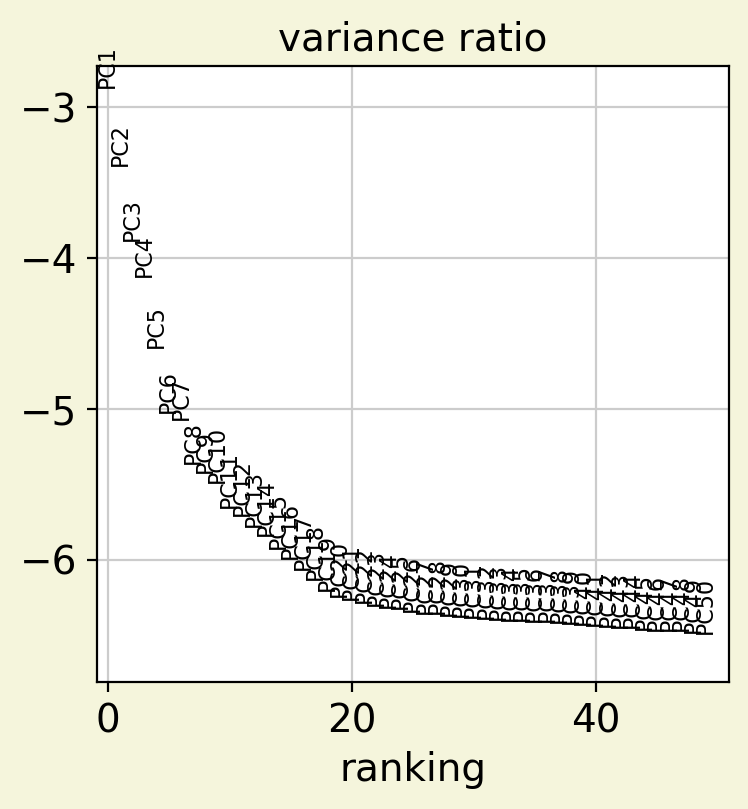

CPU times: user 13.7 s, sys: 3.21 s, total: 16.9 s
Wall time: 17.5 s


In [6]:
%%time
# last runtime: 17.5s
rsc.get.anndata_to_GPU(adata)################################################################################

# --- QC Filtering genes for min cells and cells for min genes -----------------
print(  adata.shape)
rsc.pp.filter_cells(adata, min_genes=500) # min genes per cell
print(  f'{adata.shape} after filtering out cells (min genes per cell)')
rsc.pp.filter_genes(adata, min_cells=100) # min cells per gene
print(  f'{adata.shape} after filtering out genes (min cells per gene)')

# --- Save, normalize, log transform
adata.layers['counts'] = adata.X.copy()
rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()

rsc.pp.highly_variable_genes(adata, n_top_genes=4000, 
                             flavor="seurat_v3", batch_key='dataset', 
                             layer="counts"
                            )
rsc.pp.pca(adata) # PCA
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [7]:
%%time
# last runtime: 15.8s

# --- flag mito and ribo genes -----------------

rsc.pp.flag_gene_family(adata, gene_family_name="mito", gene_family_prefix="MT") # label mt genes
rsc.pp.flag_gene_family(adata, gene_family_name="ribo", gene_family_prefix="RPS") # label ribo genes

rsc.get.anndata_to_CPU(adata)################################################################################
sc.pp.calculate_qc_metrics(adata, qc_vars=["mito", "ribo"],inplace=True) # calculate qc metrics

# --- save -----------------

adata.raw = adata 

# --- remove cells with mt genes above threshold percent  -----------------

adata[adata.obs['pct_counts_mito'] < 20] # remove cell if pct mt count is above 20%
print(f'{adata.shape} after filtering out cells (percent mt genes)')

# --- disallow gene categories using filter pass column -----------------

adata.var['filter_pass'] = True # set the gene filter
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass']) # disallow mt genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass']) # disallow ribo genes
print(  adata.var['filter_pass'].value_counts().to_string())

# --- annotate genes ---------

gdf = gene.copy()
gdf = gdf[gdf['gene_name'].isin(adata.var_names)].drop_duplicates(subset='gene_name') # Extract genes that are present in adata
adata.var = pd.concat([adata.var, gdf.set_index('gene_name')], axis=1) # merge annotations with adata
print(blue(f"Gene annotations successfully merged into adata.var."))

# add dataset column

adata.obs['dataset'] = 'myofiber'

(42513, 14372) after filtering out cells (percent mt genes)
filter_pass
True     14166
False      206
Gene annotations successfully merged into adata.var.
CPU times: user 10.1 s, sys: 5.56 s, total: 15.7 s
Wall time: 15.8 s


In [124]:
%%time
# runtimes: 1.8s+
rsc.get.anndata_to_GPU(adata)################################################################################

rsc.pp.neighbors(adata,n_neighbors=20,random_state=400,n_pcs=50) # compute nearest neighbors
rsc.tl.leiden(adata, random_state=400, resolution=0.40)
rsc.tl.umap(adata, random_state=400)

# palette = custom_cycle

CPU times: user 2.52 s, sys: 844 ms, total: 3.36 s
Wall time: 3.4 s


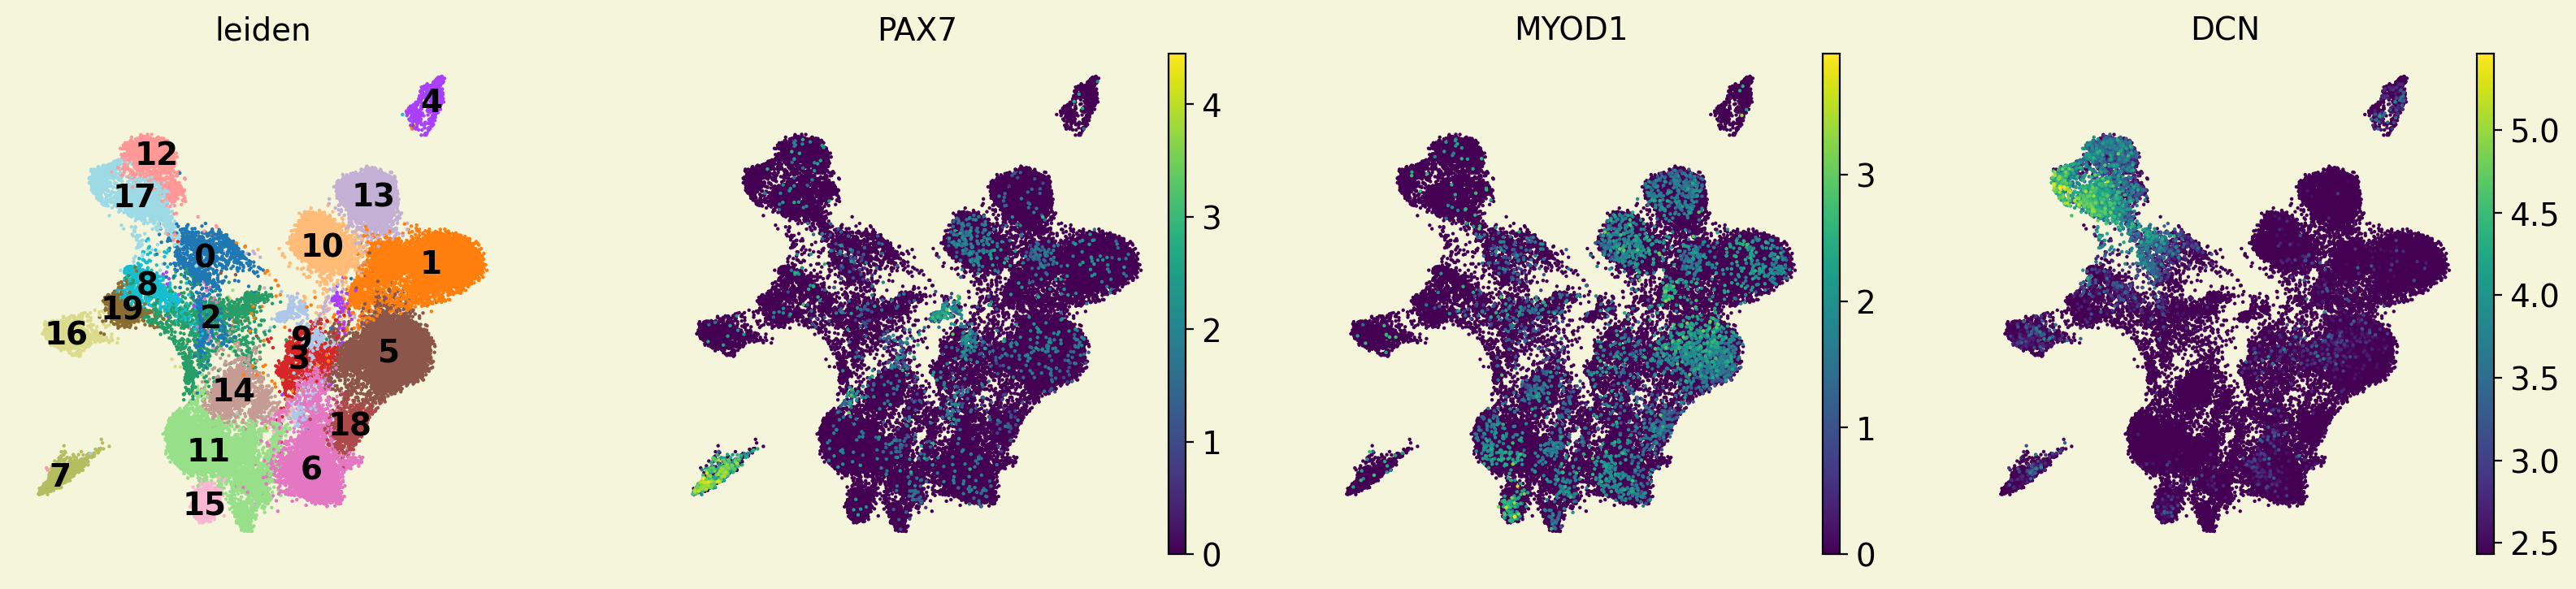

CPU times: user 1.4 s, sys: 154 ms, total: 1.56 s
Wall time: 1.59 s


In [125]:
%%time
# rsc.get.anndata_to_CPU(adata)
sc.settings.set_figure_params(frameon=False,dpi=100,color_map='viridis') # scanpy plot settings

color = ['leiden','PAX7','MYOD1','DCN']

sc.pl.umap(adata, 
           color=color,
           legend_loc='on data',
           # vmax='p99',
           vmin='p90',
           size=10,
           color_map='viridis'
              )

# embedding density

In [103]:
%%time
# Gaussian kernel density estimation is used to calculate the density of cells in an embedded space. 
sc.tl.embedding_density(adata, basis='umap')
rsc.get.anndata_to_CPU(adata)################################################################################
sc.tl.embedding_density(adata, basis='umap', groupby='leiden')

plt.rc('figure',dpi=150)
sc.pl.embedding_density(adata, basis='umap', key='umap_density_leiden', group='12',fg_dotsize=5,color_map='Spectral_r' )

# edit metadata

In [137]:
# add source column for myofiber datasets
adata.obs['source'] = adata.obs.index.str[-4:]
adata.obs

,dataset,n_counts,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,...,total_counts_mito,log1p_total_counts_mito,pct_counts_mito,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,leiden,umap_density_leiden,umap_density,source
AAACCTGAGTACGCCC-HM05,myofiber,1349.0,648,648,6.475433,1505.245605,7.317376,12.593131,21.792045,36.612657,...,16.172112,2.843287,1.074384,6.389298,2.000033,0.424469,10,0.399471,0.360486,HM05
AAACCTGAGTGGTCCC-HM05,myofiber,1561.0,823,823,6.714171,1805.258301,7.499013,10.284220,17.978339,30.899661,...,14.639424,2.749795,0.810932,2.002311,1.099382,0.110915,10,0.504814,0.477199,HM05
AAACCTGGTAAGAGAG-HM05,myofiber,1403.0,795,793,6.677083,1790.275635,7.490683,9.824685,17.438741,30.556327,...,27.047386,3.333895,1.510795,10.482574,2.440830,0.585528,11,0.218328,0.318253,HM05
AAACCTGGTACCAGTT-HM05,myofiber,1633.0,827,827,6.719013,1760.854248,7.474122,9.978994,17.315777,30.086844,...,16.948164,2.887488,0.962497,8.474083,2.248560,0.481248,11,0.170016,0.348569,HM05
AAACCTGGTAGTAGTA-HM05,myofiber,1479.0,610,609,6.413459,1399.156006,7.244339,14.348600,24.267891,40.082121,...,42.368622,3.769736,3.028156,44.478062,3.817230,3.178921,3,0.675004,0.121893,HM05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCATGCTCC-HM22,myofiber,1270.0,679,679,6.522093,1594.510254,7.374949,11.410622,20.248072,34.417600,...,20.668663,3.075867,1.296239,11.550790,2.529784,0.724410,11,0.363552,0.612010,HM22
TTTGTCATCCAAGCCG-HM22,myofiber,1734.0,822,822,6.712956,1714.374146,7.447387,10.158791,17.533048,30.627674,...,17.145639,2.898430,1.000111,9.560299,2.357102,0.557655,11,0.166684,0.449861,HM22
TTTGTCATCCGTAGGC-HM22,myofiber,2514.0,1128,1128,7.029088,2028.892700,7.615738,8.564669,14.655645,25.460862,...,11.171949,2.499134,0.550643,11.234811,2.504285,0.553741,14,0.697966,0.345723,HM22
TTTGTCATCGATCCCT-HM22,myofiber,2753.0,1254,1250,7.131699,2182.880859,7.688859,7.929981,13.739413,23.787792,...,14.160565,2.718698,0.648710,12.852795,2.628487,0.588800,14,0.997187,0.360648,HM22


In [1]:
adata.obs

NameError: name 'adata' is not defined

In [ ]:
# """ differential expression analysis """        
    
rsc.get.anndata_to_CPU(x) # adata to CPU

n_genes = 35
analysis = f'deg_top{n_genes}'
file_label = f'_{label}_{analysis}' 

print("Getting differentially expressed genes...")

# rank genes for characterizing groups    
sc.tl.rank_genes_groups(x, groupby='cluster2', method='wilcoxon', 
                        use_raw=False, pts=True,
                       )
# make dataframe for degs
deg = sc.get.rank_genes_groups_df(x, 
                                  group=None, # get all groups for dataframe
                                  pval_cutoff=0.05, 
                                  log2fc_min=1.0, 
                                  log2fc_max=10.0,
                                 )
if save is True:
    deg.to_csv(f'{label}_deg',index=False) # save dataframe to csv

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 3
fig = sc.pl.rank_genes_groups(x, 
                              n_genes=n_genes, 
                              sharey=False, 
                              ncols=3, 
                              save=save)

# """ Get dotplot of marker genes"""  <------------------------------------ pop 

# rank_genes_groups with filtering by fc and % cells expressing
print("Finding markers in differentially expressed genes...")
sc.tl.filter_rank_genes_groups(x, 
                               groupby='cluster2',
                               min_fold_change=2)

print("Making dotplot...")

# visualize filtered genes using dotplot                            
sc.pl.rank_genes_groups_dotplot(x, 
                                key="rank_genes_groups_filtered",
                                cmap='Spectral_r',
                                save=save)

print("Scoring markers...")

# get markers from filtered genes and score
markers = x.uns['rank_genes_groups_filtered']['names'] #get marker lists
markers = [[val for val in row if pd.notna(val)] for row in markers] # remove nan
markers = dict(zip(x.obs[obs_col].unique(),markers)) # make dictionary of marker lists

# save markers as dataframe
rows = [(category, gene) for category, genes in markers.items() for gene in genes] # make list of tuples for dataframe
df = pd.DataFrame(rows, columns=['group', 'gene'])

if save is True:
    df.to_csv(f'{label}_{group_name}_markers',index=False) # save marker lists

score_list = []
for key,val in markers.items():
    sc.tl.score_genes(x, val, score_name=f'score_{key}') 
    score_list.append(f'score_{key}')

    sc.pl.umap(x,
               ncols=3, 
               sort_order=True, 
               color=sorted(score_list), 
               size=15, 
               add_outline=True, 
               palette='Spectral', 
               outline_color=('k', 'white'), 
               alpha=1, 
               frameon=False, 
               vmax='p99', 
               vmin='p10', 
               save=save,
              )

# export

In [16]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [138]:
adata.write('/nfs/turbo/umms-lindmuir/2025nsfcareer/h5ad_files/adata_myofiber.h5ad')